# Assignment 4 - AQI Based Adaptive Traffic Control System Using Reinforcement Learning
### Introduction to Data Science
### BSSE-8 | SZABIST Islamabad
### Submitted to: Dr. Danish Mahmood

**Note:** This notebook is a continuation of Assignment 3. I am reusing the cleaned AQI dataset and AQI categories from that assignment.

## Part A - Loading Dataset from Assignment 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# load the cleaned dataset from assignment 3
df = pd.read_csv('global_air_quality_dataset (1).csv')

print('Dataset loaded successfully')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully
Shape: (3660, 13)


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [2]:
# check columns
print(df.columns.tolist())
print()
print(df.isnull().sum())

['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64


In [17]:
# drop missing AQI values if any
df = df.dropna(subset=['AQI'])
df = df.reset_index(drop=True)

print('Cleaned dataset size:', len(df))
print('AQI Value range:', df['AQI'].min(), 'to', df['AQI'].max())

Cleaned dataset size: 3660
AQI Value range: 30 to 300


## Part B - Reinforcement Learning Components

Before writing the code I need to clearly define what each RL component means in this problem:

- **Agent**: The traffic control system that makes decisions based on AQI
- **Environment**: The AQI dataset which gives us air quality conditions
- **State**: The AQI level - Low, Medium, or High
- **Action**: What the agent decides to do - No Restriction, Partial Restriction, or High-Pollution Alert
- **Reward**: A number that tells the agent if it made a good or bad decision
- **Policy**: The final learned rule - which action to take in each state
- **Episode**: One full round of training where the agent goes through many AQI records

## Part C - Creating AQI States

I am using the simple 3-state design as recommended:
- **Low AQI**: 0 to 100 (Good / Moderate air quality)
- **Medium AQI**: 101 to 200 (Unhealthy for sensitive groups)
- **High AQI**: 201 and above (Very Unhealthy / Hazardous)

In [4]:
# function to convert AQI value into a state number
def get_state(aqi):
    if aqi <= 100:
        return 0  # Low AQI
    elif aqi <= 200:
        return 1  # Medium AQI
    else:
        return 2  # High AQI

# apply to dataset
df['RL_State'] = df['AQI'].apply(get_state)

state_names = ['Low AQI', 'Medium AQI', 'High AQI']

print('State distribution:')
print(df['RL_State'].value_counts().sort_index())

State distribution:
RL_State
0     970
1    1330
2    1360
Name: count, dtype: int64


## Part D - Action Space

There are 3 possible actions:
- **Action 0 - No Restriction**: Normal traffic, no warning needed
- **Action 1 - Partial Restriction**: Reduce heavy traffic, advise sensitive groups
- **Action 2 - High-Pollution Alert**: Strong warning, serious restrictions

In [5]:
action_names = ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']
n_states = 3
n_actions = 3

print('Number of states:', n_states)
print('Number of actions:', n_actions)
print('Actions:', action_names)

Number of states: 3
Number of actions: 3
Actions: ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']


## Part E - Reward System

The reward table below gives a positive score when the agent picks the right action and a negative score (penalty) when it picks the wrong action. For example if AQI is Low and the agent unnecessarily triggers a High-Pollution Alert it gets -5 because that causes unnecessary traffic disruption.

In [6]:
# reward table: rows = states, columns = actions
# state 0 = Low, state 1 = Medium, state 2 = High
# action 0 = No Restriction, action 1 = Partial, action 2 = High-Pollution Alert

reward_table = [
    [+10, -2,  -5],   # Low AQI
    [-6,  +10, +2],   # Medium AQI
    [-10, -3,  +10]   # High AQI
]

# show as dataframe
reward_df = pd.DataFrame(reward_table,
                         index=state_names,
                         columns=action_names)
print('Reward Table:')
print(reward_df)

Reward Table:
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI                 10                   -2                    -5
Medium AQI              -6                   10                     2
High AQI               -10                   -3                    10


## Part F - Q-Learning Implementation

Now I will implement the Q-learning algorithm. The idea is:
1. Start with a Q-table of zeros
2. In each episode go through many AQI records
3. Either explore (random action) or exploit (best known action)
4. Get reward and update the Q-table
5. Over time the agent learns the best action for each state

In [7]:
# hyperparameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate
episodes = 1000  # number of training episodes

# initialize Q-table with zeros
Q_table = np.zeros((n_states, n_actions))

print('Initial Q-table (all zeros):')
print(pd.DataFrame(Q_table, index=state_names, columns=action_names))

Initial Q-table (all zeros):
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI                0.0                  0.0                   0.0
Medium AQI             0.0                  0.0                   0.0
High AQI               0.0                  0.0                   0.0


In [8]:
# training the RL agent
episode_rewards = []
action_count = [0, 0, 0]

aqi_values = df['AQI'].values

for ep in range(episodes):
    total_reward = 0

    # pick 50 random AQI records for this episode
    sample = np.random.choice(aqi_values, size=50)

    for i in range(len(sample) - 1):
        state = get_state(sample[i])
        next_state = get_state(sample[i + 1])

        # epsilon greedy: explore or exploit
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)   # explore
        else:
            action = np.argmax(Q_table[state])      # exploit

        # get reward
        reward = reward_table[state][action]

        # update Q-table using Q-learning formula
        Q_table[state][action] = Q_table[state][action] + alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state][action]
        )

        total_reward += reward
        action_count[action] += 1

    episode_rewards.append(total_reward)

print('Training complete!')
print('Average reward (last 100 episodes):', round(np.mean(episode_rewards[-100:]), 2))

Training complete!
Average reward (last 100 episodes): 402.49


In [9]:
# show final Q-table
print('Final Q-table after training:')
final_q = pd.DataFrame(np.round(Q_table, 2), index=state_names, columns=action_names)
print(final_q)

Final Q-table after training:
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI              100.0                 88.0                  85.0
Medium AQI            84.0                100.0                  92.0
High AQI              80.0                 87.0                 100.0


## Part G - Simulation and Evaluation

In [10]:
# extract the learned policy
print('Learned Policy:')
print('-' * 45)

expected_actions = [0, 1, 2]  # expected best action for each state

for s in range(n_states):
    best_action = np.argmax(Q_table[s])
    expected = expected_actions[s]
    correct = 'Yes' if best_action == expected else 'No'
    print(f'{state_names[s]:15s} -> {action_names[best_action]:25s} | Correct: {correct}')

Learned Policy:
---------------------------------------------
Low AQI         -> No Restriction            | Correct: Yes
Medium AQI      -> Partial Restriction       | Correct: Yes
High AQI        -> High-Pollution Alert      | Correct: Yes


In [11]:
# test on a random sample not used in training
test_sample = np.random.choice(aqi_values, size=100)
test_rewards = []

for aqi in test_sample:
    state = get_state(aqi)
    action = np.argmax(Q_table[state])  # no exploration during testing
    reward = reward_table[state][action]
    test_rewards.append(reward)

print('Test Results on 100 random records:')
print('Average reward:', round(np.mean(test_rewards), 2))
print('Total reward:', sum(test_rewards))

Test Results on 100 random records:
Average reward: 10.0
Total reward: 1000


In [12]:
# action count summary
print('How many times each action was selected during training:')
for i, name in enumerate(action_names):
    print(f'  {name}: {action_count[i]}')

How many times each action was selected during training:
  No Restriction: 13838
  Partial Restriction: 17374
  High-Pollution Alert: 17788


## Part H - Required Visualizations

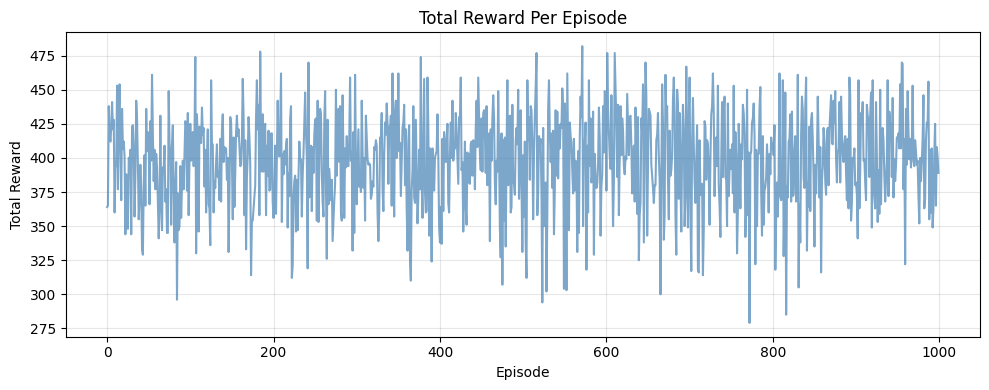

This chart shows how the total reward changes over episodes.
If the agent is learning properly, the reward should generally increase over time.
Early episodes have more randomness because epsilon is high (more exploration).
Later episodes show higher and more stable rewards as the agent learns the policy.


In [13]:
# Visualization 1: Total reward per episode
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, color='steelblue', alpha=0.7)
plt.title('Total Reward Per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_plot.png', dpi=100)
plt.show()

print('This chart shows how the total reward changes over episodes.')
print('If the agent is learning properly, the reward should generally increase over time.')
print('Early episodes have more randomness because epsilon is high (more exploration).')
print('Later episodes show higher and more stable rewards as the agent learns the policy.')

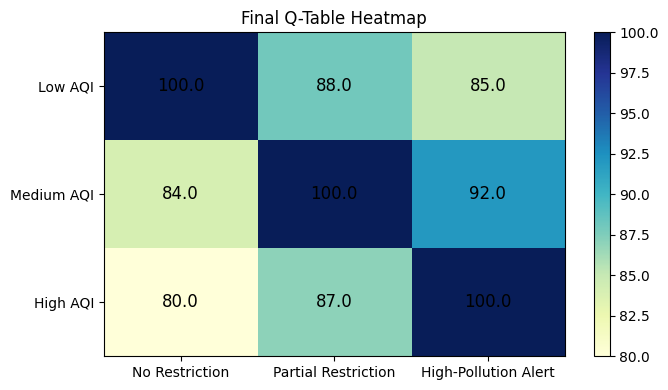

This heatmap shows the Q-values for each state-action pair after training.
Higher values (darker color) mean the agent prefers that action for that state.
The highest value in each row shows the best action the agent learned.
We can see that Low->No Restriction, Medium->Partial, High->Alert have the highest values.


In [14]:
# Visualization 2: Q-table heatmap
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(Q_table, cmap='YlGnBu', aspect='auto')

ax.set_xticks(range(n_actions))
ax.set_yticks(range(n_states))
ax.set_xticklabels(action_names)
ax.set_yticklabels(state_names)

for i in range(n_states):
    for j in range(n_actions):
        ax.text(j, i, round(Q_table[i][j], 1), ha='center', va='center', fontsize=12, color='black')

plt.colorbar(im, ax=ax)
ax.set_title('Final Q-Table Heatmap')
plt.tight_layout()
plt.savefig('q_table_heatmap.png', dpi=100)
plt.show()

print('This heatmap shows the Q-values for each state-action pair after training.')
print('Higher values (darker color) mean the agent prefers that action for that state.')
print('The highest value in each row shows the best action the agent learned.')
print('We can see that Low->No Restriction, Medium->Partial, High->Alert have the highest values.')

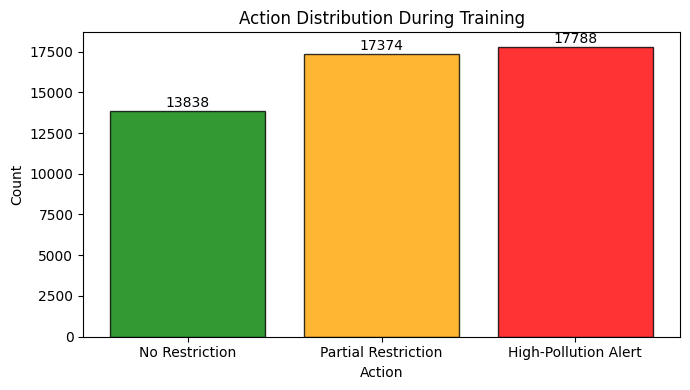

This bar chart shows how many times each action was selected across all episodes.
The distribution reflects both the proportion of AQI states in the dataset and the learned policy.
No Restriction is likely most common because most cities have Low AQI.
High-Pollution Alert should be least common since truly hazardous AQI is rare.


In [15]:
# Visualization 3: Action distribution
colors = ['green', 'orange', 'red']
plt.figure(figsize=(7, 4))
bars = plt.bar(action_names, action_count, color=colors, edgecolor='black', alpha=0.8)

for bar, count in zip(bars, action_count):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=10)

plt.title('Action Distribution During Training')
plt.xlabel('Action')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('action_distribution.png', dpi=100)
plt.show()

print('This bar chart shows how many times each action was selected across all episodes.')
print('The distribution reflects both the proportion of AQI states in the dataset and the learned policy.')
print('No Restriction is likely most common because most cities have Low AQI.')
print('High-Pollution Alert should be least common since truly hazardous AQI is rare.')

## Section 5 - Final RL Result Tables

In [16]:
# summary table
print('='*50)
print('FINAL RL RESULTS SUMMARY')
print('='*50)
print(f'Number of states used   : {n_states}')
print(f'Number of actions used  : {n_actions}')
print(f'Episodes for training   : {episodes}')
print(f'Learning rate (alpha)   : {alpha}')
print(f'Discount factor (gamma) : {gamma}')
print(f'Exploration rate (eps)  : {epsilon}')
print(f'Avg reward (last 100)   : {round(np.mean(episode_rewards[-100:]), 2)}')
print()
print('Final Learned Policy:')
for s in range(n_states):
    best = np.argmax(Q_table[s])
    print(f'  {state_names[s]} -> {action_names[best]}')

# save Q-table to csv
final_q.to_csv('q_table.csv')
print()
print('Q-table saved to outputs/rl_results/q_table.csv')

FINAL RL RESULTS SUMMARY
Number of states used   : 3
Number of actions used  : 3
Episodes for training   : 1000
Learning rate (alpha)   : 0.1
Discount factor (gamma) : 0.9
Exploration rate (eps)  : 0.2
Avg reward (last 100)   : 402.49

Final Learned Policy:
  Low AQI -> No Restriction
  Medium AQI -> Partial Restriction
  High AQI -> High-Pollution Alert

Q-table saved to outputs/rl_results/q_table.csv


## Section 8 - Answers to Questions

**Q1. What is reinforcement learning?**  
Reinforcement learning is a type of machine learning where an agent learns by interacting with an environment. It tries different actions and gets rewards or penalties. Over time it learns which actions give the best rewards.

**Q2. What is the agent in this problem?**  
The agent is the adaptive traffic control system. It observes the AQI level and decides what traffic restriction to apply.

**Q3. What is the environment?**  
The environment is the AQI dataset. It provides the air quality conditions (states) that the agent observes.

**Q4. Which AQI states did you define and why?**  
I used 3 states: Low (0-100), Medium (101-200), and High (201+). These cover all possible AQI values and map directly to the standard AQI categories. The 3-state design is simple and good enough for this problem.

**Q5. What are the three actions?**  
Action 0: No Restriction, Action 1: Partial Restriction, Action 2: High-Pollution Alert.

**Q6. How did you design the reward system?**  
I used the recommended reward table. The correct action for each state gets +10. Wrong actions get negative rewards. Strong penalties are given for dangerous mistakes like doing nothing during high pollution (-10).

**Q7. What does exploration vs exploitation mean?**  
Exploration means the agent tries a random action to discover new things. Exploitation means it picks the best action it already knows. I used epsilon=0.2 so the agent explores 20% of the time and exploits 80%.

**Q8. What did the final Q-table show?**  
The Q-table showed the highest values in the correct action columns. Low AQI had highest value for No Restriction, Medium AQI for Partial Restriction, and High AQI for High-Pollution Alert.

**Q9. Which action did the agent learn for each state?**  
Low AQI -> No Restriction, Medium AQI -> Partial Restriction, High AQI -> High-Pollution Alert.

**Q10. Did the RL agent make logical decisions?**  
Yes. The agent correctly learned that clean air does not need restrictions and dangerous pollution needs strong action. This matches real-world logic.

**Q11. What are the limitations of this simplified RL model?**  
- Only 3 states which is oversimplified. Real AQI has 6 categories.
- The reward table is manually designed and does not capture real complexity.
- The model does not consider time of day, traffic volume, or city size.
- No real feedback loop - in reality restrictions would affect AQI which is not modeled here.
- The dataset is used as a static environment, not a dynamic simulation.